# Readout-error mitigation

This notebook demonstrates the repository's sparse REM implementation and compares two local paths:

1. the local NumPy/SciPy reference
2. the local C++ extension

In [1]:
import warnings
import importlib
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit.quantum_info import hellinger_fidelity

import benchmark_rem as benchmark_rem_module
from sparse_rem import mitigate_readout_errors

# Reload local benchmark helpers after edits without restarting Jupyter.
benchmark_rem_module = importlib.reload(benchmark_rem_module)

from benchmark_rem import (
    CORE_VARIANT_LABELS,
    benchmark_local_core,
    count_two_qubit_gates,
    load_core_scaling_rows,
    load_q64_memory_rows,
    load_rows,
    make_deep_ghz_circuit,
    next_report_path,
    plot_core_scaling,
    plot_q64_memory,
    plot_scaling,
    print_q64_memory_summary,
    print_summary,
    run_benchmark,
    run_isolated_core_scaling,
    run_q64_memory_benchmark,
    summarize_rows,
)

SHOTS = 20_000
SEED = 2026
noisy_backend = AerSimulator.from_backend(FakeManilaV2(), seed_simulator=SEED)
ideal_backend = AerSimulator(seed_simulator=SEED)

## Helpers

`ideal_probs` gives the noise-free reference distribution; `report` prints the
Hellinger fidelity to that reference before and after mitigation; `plot_comparison`
draws ideal / noisy / mitigated side by side.

In [2]:
def ideal_probs(circuit):
    counts = ideal_backend.run(circuit, shots=SHOTS).result().get_counts()
    counts = {s.replace(" ", ""): c for s, c in counts.items()}
    total = sum(counts.values())
    return {s: c / total for s, c in counts.items()}


def report(ideal, out, label):
    f_noisy = hellinger_fidelity(ideal, out["raw"])
    f_mit = hellinger_fidelity(ideal, out["mitigated"])
    print(f"{label}")
    print(f"  measured physical qubits: {out['measured_physical_qubits']}")
    print(f"  Hellinger fidelity  noisy={f_noisy:.4f}  mitigated={f_mit:.4f}"
          f"  (improvement {f_mit - f_noisy:+.4f})")
    return f_noisy, f_mit


SERIES = {"Ideal": "#2a78d6", "Noisy": "#eb6834", "Mitigated": "#1baf7a"}


def plot_comparison(ideal, out, title, top=8):
    dists = [ideal, out["raw"], out["mitigated"]]
    states = sorted(set().union(*dists), key=lambda s: -ideal.get(s, 0))[:top]
    x = np.arange(len(states))
    width = 0.27

    fig, ax = plt.subplots(figsize=(max(6, len(states) * 0.95), 4.2))
    for i, (name, color) in enumerate(SERIES.items()):
        ax.bar(x + (i - 1) * width, [dists[i].get(s, 0) for s in states],
               width, label=name, color=color, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels(states, fontfamily="monospace")
    ax.set_ylabel("probability")
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", color="#e6e6e6", zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, ncols=3, loc="upper right")
    fig.tight_layout()
    plt.show()

## Example 1: GHZ state, all qubits measured

A 4-qubit GHZ state should yield only `0000` and `1111`. Readout noise leaks
weight into neighbouring strings; mitigation restores the bimodal distribution.

GHZ (4 qubits, full measurement, C++)
  measured physical qubits: [0, 1, 2, 3]
  Hellinger fidelity  noisy=0.8247  mitigated=0.9828  (improvement +0.1581)
C++ diagnostics: {'selected_backend': 'dense', 'selected_solver': 'direct', 'selected_graph_strategy': 'auto', 'selected_sparse_storage': 'auto', 'selected_orthogonalization': 'modified_gram_schmidt', 'input_states': 16, 'unique_states': 16, 'retained_edges': 176, 'hamming_ball_size': 11, 'estimated_memory_bytes': 3392, 'peak_working_memory_bytes': 3392, 'iterations': 0, 'threads': 1, 'sampled_density': 0.6875, 'residual_norm': 5.598515997148304e-17, 'relative_residual': 9.526737098188014e-17, 'setup_seconds': 1.8375e-05, 'solve_seconds': 2.0917e-05, 'projection_seconds': 0.0, 'converged': True, 'used_safe_element_fallback': False, 'jacobi_had_zero_diagonal': False, 'backend_reason': 'dense direct solve is retained for K <= 32', 'threading_backend': 'std::jthread', 'warning': '', 'backend_impl': 'cpp', 'device_seconds': 0.16314649581

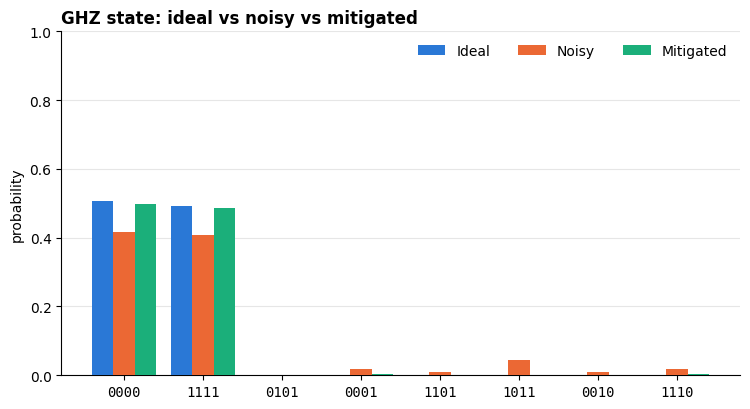

In [3]:
n = 4
ghz = QuantumCircuit(n)
ghz.h(0)
for q in range(n - 1):
    ghz.cx(q, q + 1)
ghz.measure_all()

ghz_ideal = ideal_probs(ghz)
ghz_out = mitigate_readout_errors(
    ghz,
    noisy_backend,
    shots=SHOTS,
    local=True,
    matrix_format="auto",
    seed_transpiler=SEED,
    backend_impl="cpp",
    project_to_probability_simplex=True,
    return_diagnostics=True,
    d=2,
)

report(ghz_ideal, ghz_out, "GHZ (4 qubits, full measurement, C++)")
print("C++ diagnostics:", ghz_out["diagnostics"])
plot_comparison(ghz_ideal, ghz_out, "GHZ state: ideal vs noisy vs mitigated")

## Example 2: partial measurement (a strict subset of qubits)

Sampler-mode workloads (e.g. amplitude estimation) often measure only part of
the register. Here a 4-qubit circuit prepares $\ket{1}$ on three qubits and measures
only those three into a 3-bit register; the fourth qubit is left unmeasured. The
mitigator must drive the confusion-matrix reduction by the *measured* qubits, so
the result stays a 3-bit distribution peaked at `111`.

Partial measurement (3 of 4 qubits, C++)
  measured physical qubits: [0, 1, 2]
  Hellinger fidelity  noisy=0.8535  mitigated=1.0000  (improvement +0.1465)
C++ diagnostics: {'selected_backend': 'dense', 'selected_solver': 'direct', 'selected_graph_strategy': 'auto', 'selected_sparse_storage': 'auto', 'selected_orthogonalization': 'modified_gram_schmidt', 'input_states': 7, 'unique_states': 7, 'retained_edges': 43, 'hamming_ball_size': 7, 'estimated_memory_bytes': 980, 'peak_working_memory_bytes': 980, 'iterations': 0, 'threads': 1, 'sampled_density': 0.8775510204081632, 'residual_norm': 1.1465021458541857e-16, 'relative_residual': 1.3348140719447417e-16, 'setup_seconds': 9.416e-06, 'solve_seconds': 9.791e-06, 'projection_seconds': 0.0, 'converged': True, 'used_safe_element_fallback': False, 'jacobi_had_zero_diagonal': False, 'backend_reason': 'dense direct solve is retained for K <= 32', 'threading_backend': 'std::jthread', 'warning': '', 'backend_impl': 'cpp', 'device_seconds': 0.11794

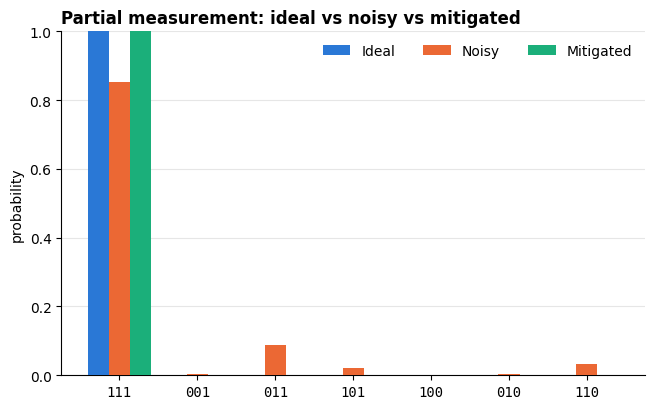

In [4]:
num_measured = 3
qreg = QuantumRegister(4, "q")
creg = ClassicalRegister(num_measured, "c")
partial = QuantumCircuit(qreg, creg)
for q in range(num_measured):
    partial.x(q)
partial.measure(range(num_measured), range(num_measured))

partial_ideal = ideal_probs(partial)
partial_out = mitigate_readout_errors(
    partial,
    noisy_backend,
    shots=SHOTS,
    local=True,
    matrix_format="auto",
    seed_transpiler=SEED,
    backend_impl="cpp",
    project_to_probability_simplex=True,
    return_diagnostics=True,
    d=2,
)

report(partial_ideal, partial_out, "Partial measurement (3 of 4 qubits, C++)")
print("C++ diagnostics:", partial_out["diagnostics"])
assert all(len(state) == num_measured for state in partial_out["mitigated"])
assert max(partial_out["mitigated"], key=partial_out["mitigated"].get) == "1" * num_measured
plot_comparison(partial_ideal, partial_out, "Partial measurement: ideal vs noisy vs mitigated")

## Performance comparison

In [5]:
core_rows = benchmark_local_core(
    n_qubits=16,
    unique_states=1_000,
    max_hamming_distance=3,
    warmups=1,
    repeats=7,
    seed=2026,
)
print_summary(core_rows)

cpp_differences = [
    row["max_abs_difference_from_python"]
    for row in core_rows
    if row["implementation"] == "cpp" and row["status"] == "ok"
]
if not cpp_differences:
    raise RuntimeError("No successful C++ runs were produced")
print("Maximum |C++ - Python|:", max(cpp_differences))

scope          states implementation  wall median   vs Python
local_core       1000 cpp               0.002830s      2.822x
local_core       1000 python            0.007985s      1.000x
Maximum |C++ - Python|: 1.1490850960873612e-09


### Large-matrix scaling: sequential powers of two

The measured sweep uses every integer power from $2^8$ through $2^{14}$, so the requested reduced state space grows smoothly from 256 to 16,384 states. Each point has three repetitions and compares only the local Python and C++ implementations. No cloud backend is used.

The runtime chart reports median end-to-end wall time. The memory chart reports peak local-process RSS. Both implementations receive the same circuit family, state-space sizes, shot counts and repetition count. Failed runs are omitted from the plots.

In [6]:
SCALING_POWERS = range(8, 15)  # 2**8 ... 2**14 inclusive
SCALING_SIZES = [2**power for power in SCALING_POWERS]
SCALING_REPEATS = 3
SCALING_SHOTS_PER_STATE = 4
SCALING_IMPLEMENTATIONS = ("python", "cpp")
SCALING_REPORT = Path("results/local_python_cpp_scaling.csv")
REUSE_EXISTING_SCALING_RESULTS = True

if REUSE_EXISTING_SCALING_RESULTS and SCALING_REPORT.exists():
    scaling_report = SCALING_REPORT
    scaling_rows = [
        row
        for row in load_rows(scaling_report)
        if row["implementation"] in SCALING_IMPLEMENTATIONS
        and int(row["requested_states"]) in SCALING_SIZES
    ]
    print(
        f"Loaded {len(scaling_rows)} local Python/C++ rows from "
        f"{scaling_report}"
    )
else:
    scaling_report = next_report_path(Path("results"))
    scaling_rows = run_benchmark(
        sizes=SCALING_SIZES,
        implementations=list(SCALING_IMPLEMENTATIONS),
        shots_per_state=SCALING_SHOTS_PER_STATE,
        warmups=0,
        repeats=SCALING_REPEATS,
        haiqu_cooldown_seconds=0.0,
        output_path=scaling_report,
    )

print_summary(scaling_rows)

Loaded 42 local Python/C++ rows from results/local_python_cpp_scaling.csv
scope          states implementation  wall median  device median   vs Python
end_to_end        256 cpp               0.057242s      0.033277s      1.034x
end_to_end        256 python            0.059174s      0.024797s      1.000x
end_to_end        512 cpp               0.055587s      0.033498s      1.304x
end_to_end        512 python            0.072506s      0.037689s      1.000x
end_to_end       1024 cpp               0.099012s      0.066395s      1.619x
end_to_end       1024 python            0.160328s      0.063885s      1.000x
end_to_end       2048 cpp               0.171230s      0.135461s      2.345x
end_to_end       2048 python            0.401613s      0.226329s      1.000x
end_to_end       4096 cpp               0.304526s      0.266572s      2.045x
end_to_end       4096 python            0.622730s      0.336325s      1.000x
end_to_end       8192 cpp               0.598464s      0.536994s      2.333x
en

Runtime plot saved to: /Users/nikitalenyk/Desktop/qml-hackaton/results/figs/local_python_cpp_scaling_runtime.svg
Memory plot saved to: /Users/nikitalenyk/Desktop/qml-hackaton/results/figs/local_python_cpp_scaling_memory.svg


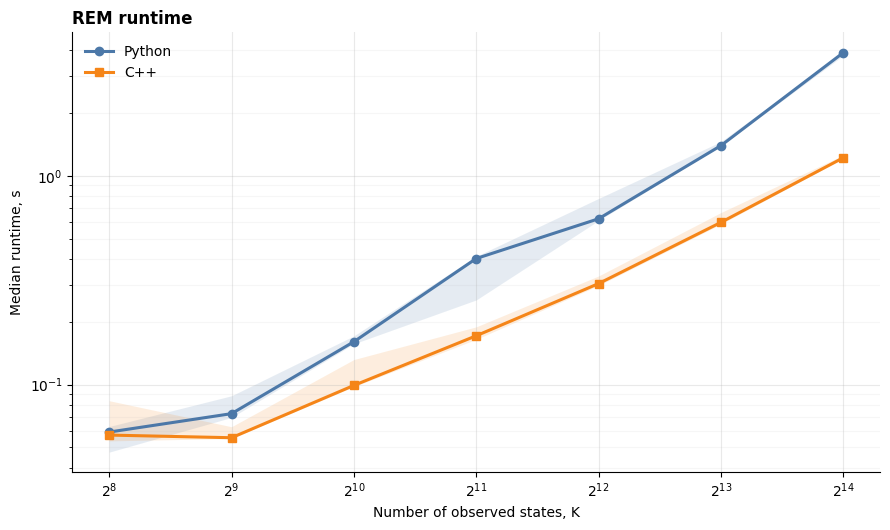

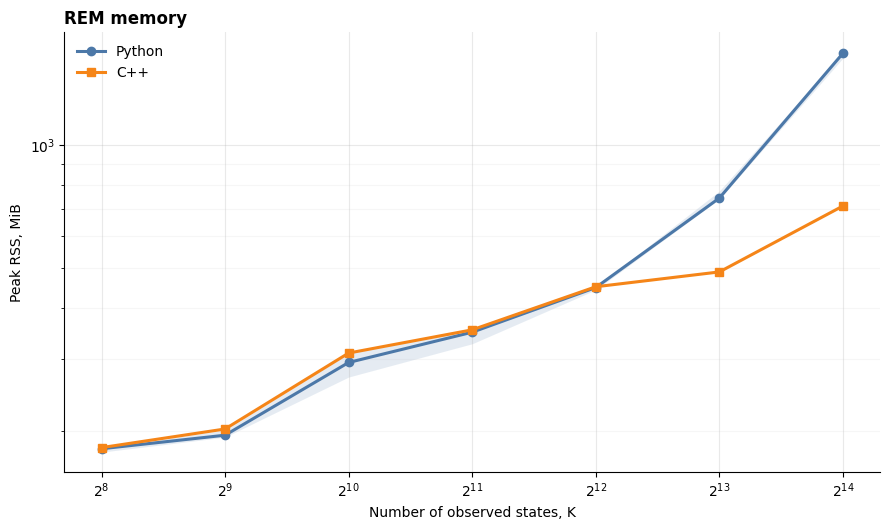

In [7]:
runtime_figure, memory_figure = plot_scaling(
    scaling_rows,
    output_directory=Path("results/figs"),
    filename_prefix=scaling_report.stem,
)
plt.show()

### 23-qubit deep-circuit benchmark (opt in)

This benchmark builds a 23-qubit GHZ circuit at depth 30 and uses Aer's matrix-product-state simulator. Random `RZ` and alternating `CZ` layers deepen the circuit without changing its ideal two-state measurement distribution. Python and C++ receive the same circuit, shot count, readout-noise model and mitigation settings.

Keep `RUN_DEEP_BENCHMARK = False` for a construction-only preview. Enabling it runs only the local Python and C++ implementations; no cloud jobs are submitted.

In [8]:
DEEP_QUBITS = 23
DEEP_TARGET_DEPTH = 30
DEEP_SHOTS = 10_000
DEEP_REPEATS = 3
RUN_DEEP_BENCHMARK = True

deep_circuit = make_deep_ghz_circuit(DEEP_QUBITS, DEEP_TARGET_DEPTH)
print(
    f"Deep benchmark preview: {deep_circuit.num_qubits} qubits, "
    f"depth={deep_circuit.depth()}, "
    f"two-qubit gates={count_two_qubit_gates(deep_circuit)}"
)

if RUN_DEEP_BENCHMARK:
    deep_report = next_report_path(Path("results"))
    deep_rows = run_benchmark(
        sizes=None,
        qubits=DEEP_QUBITS,
        target_depth=DEEP_TARGET_DEPTH,
        fixed_shots=DEEP_SHOTS,
        implementations=["python", "cpp"],
        warmups=0,
        repeats=DEEP_REPEATS,
        shots_per_state=1,
        output_path=deep_report,
    )
    print_summary(deep_rows)
else:
    print("Set RUN_DEEP_BENCHMARK=True to execute this benchmark.")

Deep benchmark preview: 23 qubits, depth=30, two-qubit gates=55

Deep-circuit mode: 23 qubits, target depth 30, actual depth 30, 55 two-qubit gates, 10000 shots
  python
    measured run 1/3
      wall=0.639s, peak=266.4MiB, fidelity=0.8545
    measured run 2/3
      wall=0.621s, peak=274.6MiB, fidelity=0.8545
    measured run 3/3
      wall=0.563s, peak=281.9MiB, fidelity=0.8545
  cpp
    measured run 1/3
      wall=0.474s, peak=281.9MiB, fidelity=0.8545
    measured run 2/3
      wall=0.475s, peak=282.0MiB, fidelity=0.8545
    measured run 3/3
      wall=0.475s, peak=282.7MiB, fidelity=0.8545

Results saved to: /Users/nikitalenyk/Desktop/qml-hackaton/results/benchmark_006.csv
scope          states implementation  wall median  device median   vs Python
end_to_end    8388608 cpp               0.475028s      0.440618s      1.307x
end_to_end    8388608 python            0.620779s      0.491703s      1.000x


## Dense, sparse and matrix-free backends

All C++ backends solve the same normalized reduced system $A p=q$. They differ only in how $A$ is represented and applied.

For observed states $S=\{s_0,\ldots,s_{K-1}\}$, per-qubit assignment matrices $C_r$, and Hamming cutoff $d$:

$$B_{ij}=\prod_{r=0}^{Q-1} C_r[s_i(r),s_j(r)]\,\mathbf{1}\{\operatorname{HD}(s_i,s_j)\le d\},\qquad z_j=\sum_i B_{ij},\qquad A_{ij}=B_{ij}/z_j.$$

The returned $p$ is a quasi-probability vector. Probability-simplex projection is an independent opt-in post-processing step.

### Dense

Dense materializes all $K^2$ positions of $A$ as aligned `float64` in column-major order, including zeros removed by the Hamming cutoff. Matrix construction checks every state pair, normalizes each source column, and passes the same column-major buffer directly to LAPACK.

The solve uses pivoted LU, $PA=LU$, through Accelerate `dgesv` on macOS. Matrix memory is approximately $8K^2$ bytes and factorization work is approximately $\frac{2}{3}K^3$ floating-point operations. Dense is appropriate for small or high-density problems and repeated right-hand sides that can reuse one factorization. Its memory grows by roughly 4x and factorization work by roughly 8x whenever $K$ doubles.

### Sparse CSR

Sparse stores only the edge set $\mathcal{E}=\{(i,j):\operatorname{HD}(s_i,s_j)\le d\}$. CSR uses `uint64` row offsets and `uint32` column indices. Valued CSR additionally stores normalized `float64` values; topology-only CSR recomputes each value from packed states during every matrix-vector product.

Valued CSR memory is approximately $8(K+1)+12E$ bytes, while topology-only CSR uses approximately $8(K+1)+4E$ bytes. The nonsymmetric system is solved with restarted left-Jacobi GMRES. A valued matvec costs $O(E)$; topology-only costs $O(Ed)$. Sparse is normally the best choice when $E\ll K^2$ and the graph fits the memory budget.

### Matrix-free

Matrix-free stores neither dense entries nor CSR topology. For each output row it generates Hamming-neighbour candidates and probes the observed-state hash table, or scans all observed states when scanning is cheaper. Every retained coefficient is evaluated as $A_{ij}=\operatorname{base}(s_j)\prod_{r\in D_{ij}}\operatorname{ratio}(r,s_j(r))/z_j$.

Operator memory does not grow with $E$, but GMRES still requires $O(Km)$ basis storage for restart length $m$. Matrix-free repeats neighbour discovery on every Krylov iteration, so it trades additional compute and hash lookups for lower memory. It is intended for cases where explicit CSR does not fit or convergence requires few iterations.

In [9]:
LOAD_EXISTING_CORE_REPORTS = True
OVERWRITE_CORE_REPORTS = True
VERIFY_CORE_RESULTS_BEFORE_RUN = True

# Python stops at K=2^13. Its pairwise distance array alone reaches
# about 1 GiB at K=2^14 and 4 GiB at K=2^15.
PYTHON_CPP_POWERS = list(range(6, 14))
# The C++-only suite does not allocate the Python O(K^2) distance array.
CPP_BACKEND_POWERS = list(range(6, 16))
# Valued CSR remains below the 6 GiB budget through Q=18.
CPP_SPARSE_EXTENDED_POWERS = list(range(16, 18))
# Matrix-free stores no graph and continues to one million states.
CPP_MATRIX_FREE_EXTENDED_POWERS = list(range(16, 19))
CPP_DENSE_MAX_POWER = 12

CORE_REPEATS = 3
CORE_WARMUPS = 1
CORE_HAMMING_CUTOFF = 3
CORE_THREADS = 0
CORE_MEMORY_BUDGET_GIB = 12
# Timeout applies to one isolated variant and matrix size, not the suite.
CORE_TIMEOUT_SECONDS = 600
ALLOW_LARGE_PYTHON_RUN = False

RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figs"
PYTHON_CPP_REPORT = RESULTS_DIR / "core_python_vs_cpp_scaling.csv"
CPP_BACKENDS_REPORT = RESULTS_DIR / "core_cpp_backends_scaling.csv"
CPP_SPARSE_EXTENDED_REPORT = RESULTS_DIR / "core_cpp_sparse_extended.csv"
CPP_MATRIX_FREE_EXTENDED_REPORT = RESULTS_DIR / "core_cpp_matrix_free_extended.csv"


def load_or_run_core_suite(*, enabled, report, suite, variants, powers):
    if enabled:
        if (
            "python_auto" in variants
            and powers
            and max(powers) > 13
            and not ALLOW_LARGE_PYTHON_RUN
        ):
            raise ValueError(
                "Python scaling above K=2^13 is disabled because "
                "sparse_rem.py materializes O(K^2) pairwise distances. "
                "Use the C++-only suite for larger K."
            )
        process_count = len(powers) * len(variants) * (
            CORE_WARMUPS + CORE_REPEATS
        )
        print(
            f"Starting {process_count} isolated worker processes; "
            f"largest K is 2^{max(powers)}."
        )
        return run_isolated_core_scaling(
            suite=suite,
            variants=variants,
            matrix_powers=powers,
            dense_max_power=CPP_DENSE_MAX_POWER,
            repeats=CORE_REPEATS,
            warmups=CORE_WARMUPS,
            max_hamming_distance=CORE_HAMMING_CUTOFF,
            threads=CORE_THREADS,
            memory_budget_bytes=CORE_MEMORY_BUDGET_GIB * 1024**3,
            output_path=report,
            overwrite=OVERWRITE_CORE_REPORTS,
            verify=VERIFY_CORE_RESULTS_BEFORE_RUN,
            timeout_seconds=CORE_TIMEOUT_SECONDS,
        )
    if LOAD_EXISTING_CORE_REPORTS and report.exists():
        rows = [
            row for row in load_core_scaling_rows(report)
            if row["variant"] in variants
        ]
        print(f"Loaded {len(rows)} selected rows from {report}")
        return rows
    print(
        f"{suite} is disabled and {report} does not exist. "
        "Enable its RUN_* flag to generate it."
    )
    return []

## Python and C++

This suite compares `sparse_rem.py` with the automatic C++ backend using identical generated states, calibration matrices, Hamming cutoff and solver tolerances. It runs by default. Set `RUN_PYTHON_VS_CPP = False` only when you want to reuse the existing CSV without rerunning the benchmark.

The Python series stops at $K=2^{13}=8192$. `sparse_rem.py` materializes $K(K-1)/2$ `float64` pairwise distances: approximately 256 MiB at $2^{13}$, 1 GiB at $2^{14}$ and 4 GiB at $2^{15}$ before other arrays are counted. The separate C++ suite continues to $2^{15}$.

In [10]:
RUN_PYTHON_VS_CPP = True
PYTHON_CPP_VARIANTS = ["python_auto", "cpp_auto"]

python_cpp_core_rows = load_or_run_core_suite(
    enabled=RUN_PYTHON_VS_CPP,
    report=PYTHON_CPP_REPORT,
    suite="python_vs_cpp",
    variants=PYTHON_CPP_VARIANTS,
    powers=PYTHON_CPP_POWERS,
)

Starting 64 isolated worker processes; largest K is 2^13.
Verification max |difference|: {'python_auto': 0.0, 'cpp_auto': 1.3877787807814457e-17}

Python, K=2^6
  isolated warmup 1/1
  measured run 1/3
    wall=0.000366s, peak RSS=87.6 MiB, backend=dense
  measured run 2/3
    wall=0.000361s, peak RSS=87.7 MiB, backend=dense
  measured run 3/3
    wall=0.000331s, peak RSS=88.3 MiB, backend=dense

C++, K=2^6
  isolated warmup 1/1
  measured run 1/3
    wall=0.000556s, peak RSS=88.2 MiB, backend=dense
  measured run 2/3
    wall=0.000565s, peak RSS=87.5 MiB, backend=dense
  measured run 3/3
    wall=0.000496s, peak RSS=88.6 MiB, backend=dense

Python, K=2^7
  isolated warmup 1/1
  measured run 1/3
    wall=0.000746s, peak RSS=87.6 MiB, backend=dense
  measured run 2/3
    wall=0.000862s, peak RSS=88.6 MiB, backend=dense
  measured run 3/3
    wall=0.000823s, peak RSS=88.5 MiB, backend=dense

C++, K=2^7
  isolated warmup 1/1
  measured run 1/3
    wall=0.000616s, peak RSS=87.9 MiB, backen

Runtime plot saved to: /Users/nikitalenyk/Desktop/qml-hackaton/results/figs/core_python_vs_cpp_runtime.svg
Memory plot saved to: /Users/nikitalenyk/Desktop/qml-hackaton/results/figs/core_python_vs_cpp_memory.svg


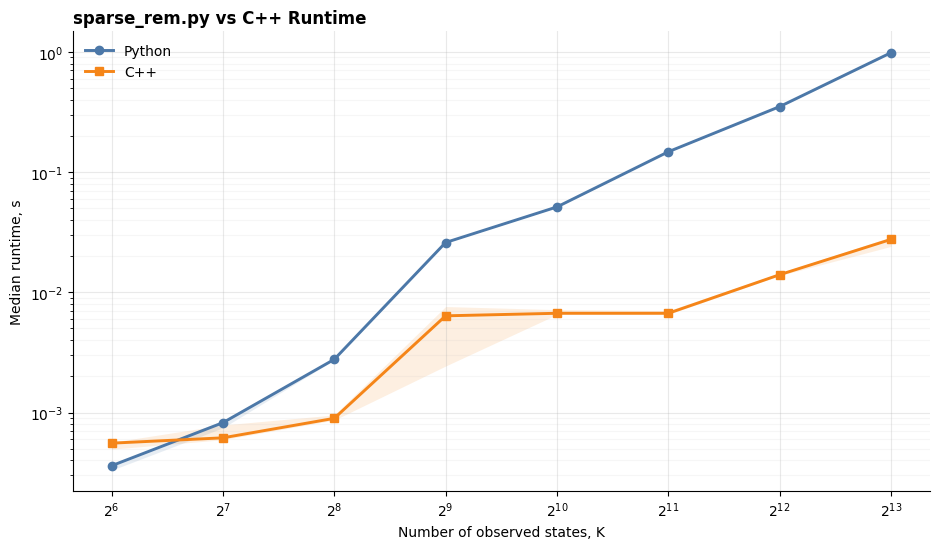

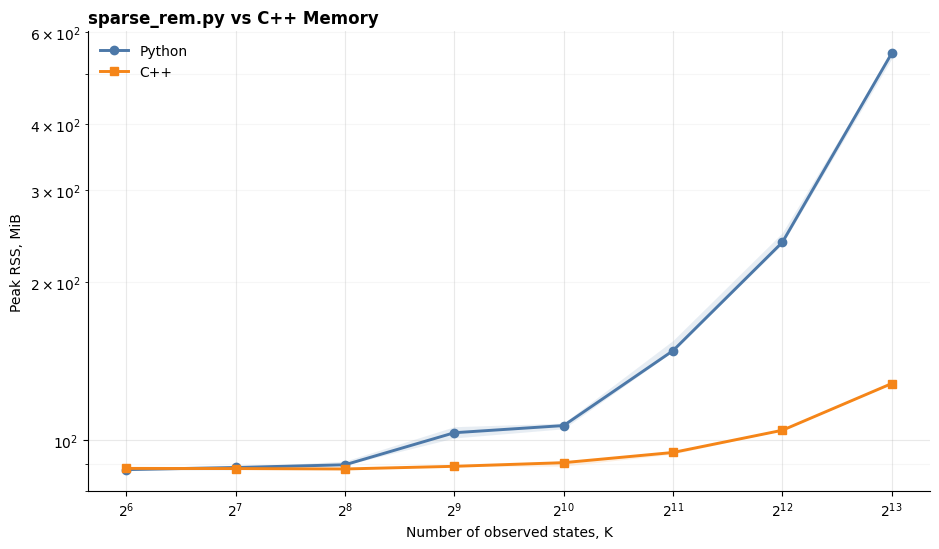

In [11]:
if python_cpp_core_rows:
    python_cpp_runtime, python_cpp_memory = plot_core_scaling(
        python_cpp_core_rows,
        title_prefix="sparse_rem.py vs C++",
        output_directory=FIGURES_DIR,
        filename_prefix="core_python_vs_cpp",
    )
    plt.show()

## C++ dense, sparse and matrix-free

This suite compares the three matrix representations directly. It excludes the automatic selector and topology-only CSR so that each curve corresponds to one of the three documented methods. It runs by default. Set `RUN_CPP_BACKENDS = False` only to reuse the existing CSV.

In [12]:
RUN_CPP_BACKENDS = True
CPP_BACKEND_VARIANTS = [
    "cpp_dense",
    "cpp_sparse_valued",
    "cpp_matrix_free",
]

cpp_backends_core_rows = load_or_run_core_suite(
    enabled=RUN_CPP_BACKENDS,
    report=CPP_BACKENDS_REPORT,
    suite="cpp_backends",
    variants=CPP_BACKEND_VARIANTS,
    powers=CPP_BACKEND_POWERS,
)

Starting 120 isolated worker processes; largest K is 2^15.
Verification max |difference|: {'cpp_dense': 0.0, 'cpp_sparse_valued': 2.3887862694860207e-10, 'cpp_matrix_free': 2.388786234791551e-10}

Dense, K=2^6
  isolated warmup 1/1
  measured run 1/3
    wall=0.000565s, peak RSS=87.9 MiB, backend=dense
  measured run 2/3
    wall=0.000552s, peak RSS=87.8 MiB, backend=dense
  measured run 3/3
    wall=0.000465s, peak RSS=87.8 MiB, backend=dense

Sparse CSR, K=2^6
  isolated warmup 1/1
  measured run 1/3
    wall=0.000142s, peak RSS=87.5 MiB, backend=explicit_sparse
  measured run 2/3
    wall=0.000177s, peak RSS=87.8 MiB, backend=explicit_sparse
  measured run 3/3
    wall=0.000144s, peak RSS=87.1 MiB, backend=explicit_sparse

Matrix-free, K=2^6
  isolated warmup 1/1
  measured run 1/3
    wall=0.000701s, peak RSS=87.3 MiB, backend=matrix_free
  measured run 2/3
    wall=0.000451s, peak RSS=88.2 MiB, backend=matrix_free
  measured run 3/3
    wall=0.000454s, peak RSS=87.3 MiB, backend=m

### Sparse CSR full-state extension

This suite continues valued CSR through $Q=18$, or $K=2^{18}=262\,144$ unique states. With $d=3$, the next point at $Q=19$ is projected to exceed the 6 GiB working-memory budget, so it is rejected by preflight rather than attempted.

In [13]:
RUN_CPP_SPARSE_EXTENSION = True

cpp_sparse_extended_rows = load_or_run_core_suite(
    enabled=RUN_CPP_SPARSE_EXTENSION,
    report=CPP_SPARSE_EXTENDED_REPORT,
    suite="cpp_sparse_extended",
    variants=["cpp_sparse_valued"],
    powers=CPP_SPARSE_EXTENDED_POWERS,
)

Starting 8 isolated worker processes; largest K is 2^17.
Verification max |difference|: {'cpp_sparse_valued': 3.3364375769551896e-11}

Sparse CSR, K=2^16
  isolated warmup 1/1
  measured run 1/3
    wall=0.306293s, peak RSS=652.6 MiB, backend=explicit_sparse
  measured run 2/3
    wall=0.302217s, peak RSS=652.1 MiB, backend=explicit_sparse
  measured run 3/3
    wall=0.316458s, peak RSS=652.3 MiB, backend=explicit_sparse

Sparse CSR, K=2^17
  isolated warmup 1/1
  measured run 1/3
    wall=0.812999s, peak RSS=1418.9 MiB, backend=explicit_sparse
  measured run 2/3
    wall=0.727579s, peak RSS=1413.6 MiB, backend=explicit_sparse
  measured run 3/3
    wall=0.783888s, peak RSS=1416.5 MiB, backend=explicit_sparse

Core scaling report saved to: /Users/nikitalenyk/Desktop/qml-hackaton/results/core_cpp_sparse_extended.csv


### Matrix-free full-state extension

Matrix-free continues through $Q=20$, or $K=2^{20}=1\,048\,576$ unique states. It stores packed states and the GMRES workspace but no $E$-dependent graph. These are computationally heavy CPU runs even though their memory estimate fits.

In [14]:
RUN_CPP_MATRIX_FREE_EXTENSION = True

cpp_matrix_free_extended_rows = load_or_run_core_suite(
    enabled=RUN_CPP_MATRIX_FREE_EXTENSION,
    report=CPP_MATRIX_FREE_EXTENDED_REPORT,
    suite="cpp_matrix_free_extended",
    variants=["cpp_matrix_free"],
    powers=CPP_MATRIX_FREE_EXTENDED_POWERS,
)

Starting 12 isolated worker processes; largest K is 2^18.
Verification max |difference|: {'cpp_matrix_free': 3.336437568823673e-11}

Matrix-free, K=2^16
  isolated warmup 1/1
  measured run 1/3
    wall=1.305858s, peak RSS=131.0 MiB, backend=matrix_free
  measured run 2/3
    wall=1.258347s, peak RSS=127.2 MiB, backend=matrix_free
  measured run 3/3
    wall=1.267933s, peak RSS=129.3 MiB, backend=matrix_free

Matrix-free, K=2^17
  isolated warmup 1/1
  measured run 1/3
    wall=3.322344s, peak RSS=164.9 MiB, backend=matrix_free
  measured run 2/3
    wall=3.481322s, peak RSS=170.8 MiB, backend=matrix_free
  measured run 3/3
    wall=3.774687s, peak RSS=164.1 MiB, backend=matrix_free

Matrix-free, K=2^18
  isolated warmup 1/1
  measured run 1/3
    wall=9.292696s, peak RSS=246.3 MiB, backend=matrix_free
  measured run 2/3
    wall=9.393997s, peak RSS=243.9 MiB, backend=matrix_free
  measured run 3/3
    wall=9.310027s, peak RSS=239.8 MiB, backend=matrix_free

Core scaling report saved t

Runtime plot saved to: /Users/nikitalenyk/Desktop/qml-hackaton/results/figs/core_cpp_backends_runtime.svg
Memory plot saved to: /Users/nikitalenyk/Desktop/qml-hackaton/results/figs/core_cpp_backends_memory.svg


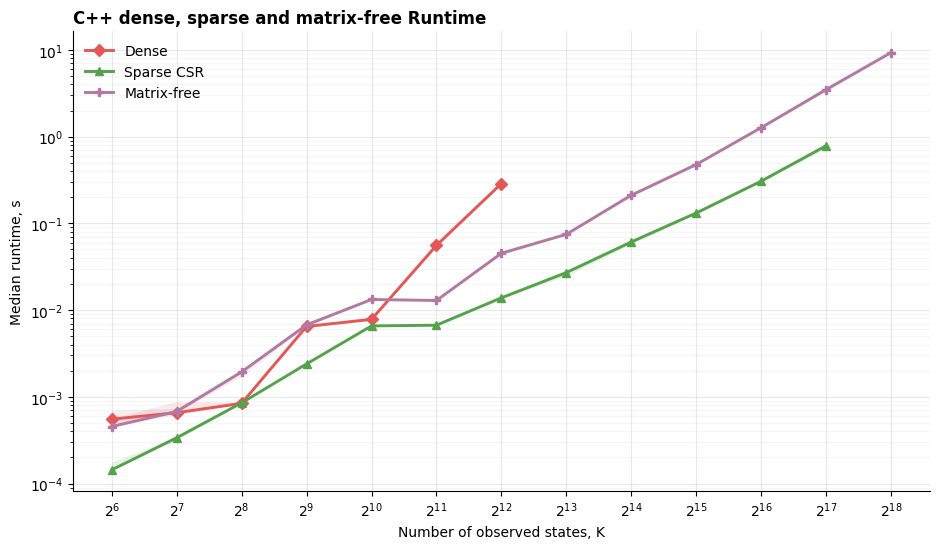

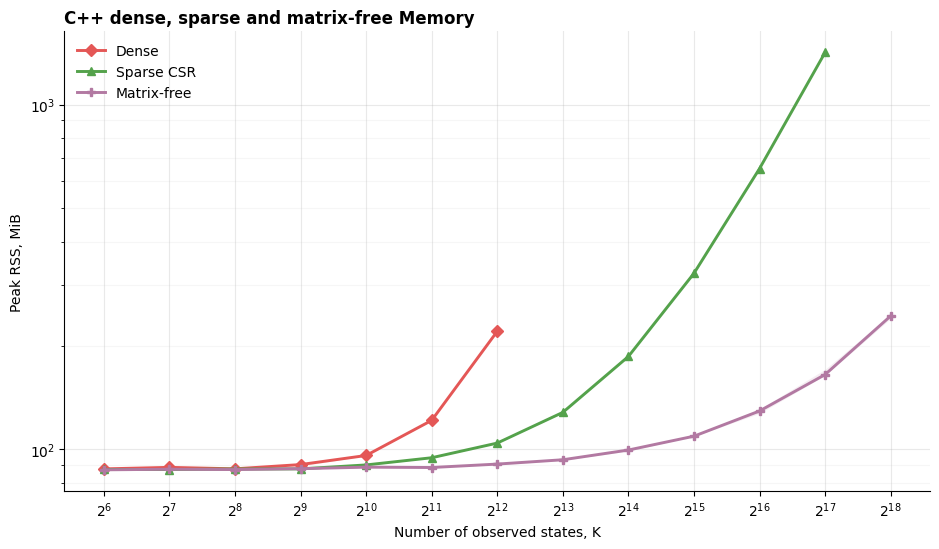

In [15]:
cpp_backend_plot_rows = (
    cpp_backends_core_rows
    + cpp_sparse_extended_rows
    + cpp_matrix_free_extended_rows
)

if cpp_backend_plot_rows:
    cpp_runtime, cpp_memory = plot_core_scaling(
        cpp_backend_plot_rows,
        title_prefix="C++ dense, sparse and matrix-free",
        output_directory=FIGURES_DIR,
        filename_prefix="core_cpp_backends",
    )
    plt.show()

## Matrix-free memory at and above 64 qubits

This isolated C++ experiment uses $Q=65$, so it exercises the generic packed-state path with two `uint64` words per state. Both backends receive the same packed states, probabilities, calibrations, Hamming cutoff and GMRES settings.

The benchmark steps through $K=2^9,2^{10},\ldots,2^{15}$ and uses two equally sized Hamming-local clusters. Every state is at distance at most three from its cluster centre, while the two centres are bitwise opposites. With cutoff $d=6$, every pair inside a cluster is retained and every cross-cluster pair is rejected. Therefore the retained edge count grows quadratically:

$$E(K)=2\left(\frac{K}{2}\right)^2=\frac{K^2}{2}.$$

Valued CSR stores a `uint32` column index and `float64` value for every edge, plus row offsets:

$$M_{\mathrm{CSR\ graph}}(K)=8(K+1)+(4+8)E(K)\approx6K^2\ \mathrm{bytes}.$$

Across the chosen steps this graph alone grows from about $1.5$ MiB at $K=512$ to $6$ GiB at $K=32768$. Matrix-free stores no edge-dependent graph, so $M_{\mathrm{MF\ graph}}=0$. It still stores packed states, calibration data, column normalizers and the GMRES basis, approximately $O(K\lceil Q/64\rceil+Km)$. The first graph reports isolated-process Peak RSS, which includes the Python runtime. The second reports the C++ working-set estimate and exposes the algorithmic difference directly. Both use logarithmic axes.

This is intentionally a high-density memory stress case. Matrix-free saves graph memory by rescanning candidate pairs on every matvec, so lower memory can come with higher runtime.

In [16]:
RUN_Q64_MEMORY_BENCHMARK = True
LOAD_EXISTING_Q64_MEMORY_REPORT = True
OVERWRITE_Q64_MEMORY_REPORT = True

Q64_MEMORY_QUBITS = [65]
Q64_MEMORY_MATRIX_POWERS = list(range(9, 16))
Q64_MEMORY_MATRIX_SIZES = [1 << power for power in Q64_MEMORY_MATRIX_POWERS]
Q64_MEMORY_CLUSTERS = 2
Q64_MEMORY_CLUSTER_RADIUS = 3
Q64_MEMORY_HAMMING_CUTOFF = 6
Q64_MEMORY_REPEATS = 3
Q64_MEMORY_WARMUPS = 1
Q64_MEMORY_THREADS = 6
Q64_MEMORY_BUDGET_GIB = 10
Q64_MEMORY_TIMEOUT_SECONDS = 600
Q64_MEMORY_REPORT = RESULTS_DIR / "q64plus_matrix_free_memory.csv"

In [17]:
if RUN_Q64_MEMORY_BENCHMARK:
    q64_memory_rows = run_q64_memory_benchmark(
        qubit_counts=Q64_MEMORY_QUBITS,
        matrix_sizes=Q64_MEMORY_MATRIX_SIZES,
        clusters=Q64_MEMORY_CLUSTERS,
        cluster_radius=Q64_MEMORY_CLUSTER_RADIUS,
        max_hamming_distance=Q64_MEMORY_HAMMING_CUTOFF,
        repeats=Q64_MEMORY_REPEATS,
        warmups=Q64_MEMORY_WARMUPS,
        threads=Q64_MEMORY_THREADS,
        memory_budget_bytes=Q64_MEMORY_BUDGET_GIB * 1024**3,
        output_path=Q64_MEMORY_REPORT,
        overwrite=OVERWRITE_Q64_MEMORY_REPORT,
        verify=True,
        timeout_seconds=Q64_MEMORY_TIMEOUT_SECONDS,
    )
elif LOAD_EXISTING_Q64_MEMORY_REPORT and Q64_MEMORY_REPORT.exists():
    q64_memory_rows = [
        row
        for row in load_q64_memory_rows(Q64_MEMORY_REPORT)
        if row["qubits"] in Q64_MEMORY_QUBITS
        and row["matrix_size"] in Q64_MEMORY_MATRIX_SIZES
    ]
    print(f"Loaded {len(q64_memory_rows)} rows from {Q64_MEMORY_REPORT}")
else:
    q64_memory_rows = []
    print("Enable RUN_Q64_MEMORY_BENCHMARK or provide an existing report.")

Verification max |Sparse CSR - Matrix-free|: 7.806e-18

Sparse CSR, Q=65, K=512, 2 word(s)/state
  isolated warmup 1/1
  measured run 1/3
    peak RSS=89.8 MiB, working set=1.6 MiB, wall=0.0011s
  measured run 2/3
    peak RSS=90.1 MiB, working set=1.6 MiB, wall=0.0012s
  measured run 3/3
    peak RSS=89.3 MiB, working set=1.6 MiB, wall=0.0053s

Matrix-free, Q=65, K=512, 2 word(s)/state
  isolated warmup 1/1
  measured run 1/3
    peak RSS=88.0 MiB, working set=0.1 MiB, wall=0.0054s
  measured run 2/3
    peak RSS=87.5 MiB, working set=0.1 MiB, wall=0.0053s
  measured run 3/3
    peak RSS=87.2 MiB, working set=0.1 MiB, wall=0.0053s

Sparse CSR, Q=65, K=1024, 2 word(s)/state
  isolated warmup 1/1
  measured run 1/3
    peak RSS=93.9 MiB, working set=6.3 MiB, wall=0.0058s
  measured run 2/3
    peak RSS=94.2 MiB, working set=6.3 MiB, wall=0.0059s
  measured run 3/3
    peak RSS=93.8 MiB, working set=6.3 MiB, wall=0.0054s

Matrix-free, Q=65, K=1024, 2 word(s)/state
  isolated warmup 1/1
 

Peak-RSS plot saved to: /Users/nikitalenyk/Desktop/qml-hackaton/results/figs/q64plus_matrix_free_peak_rss.svg
Working-set plot saved to: /Users/nikitalenyk/Desktop/qml-hackaton/results/figs/q64plus_matrix_free_working_set.svg


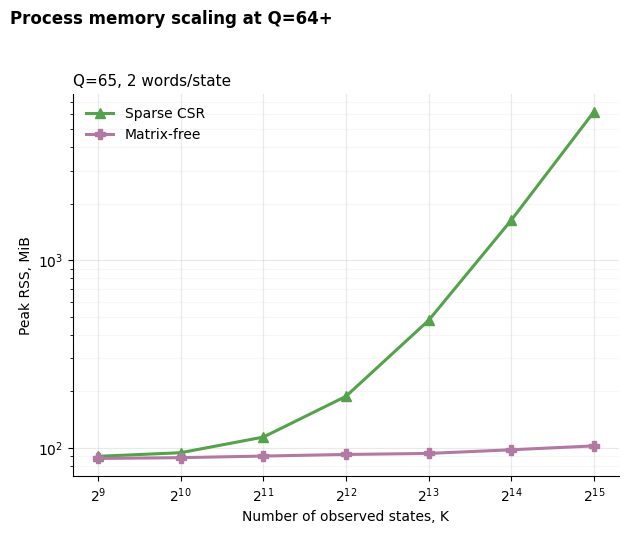

In [18]:

q64_peak_figure, q64_working_figure = plot_q64_memory(
    q64_memory_rows,
    output_directory=FIGURES_DIR,
    filename_prefix="q64plus_matrix_free",
)
display(q64_peak_figure)

In [19]:
print_q64_memory_summary(q64_memory_rows)

   Q       K words        edges    CSR RSS     MF RSS    CSR set     MF set  set ratio  MF/CSR time
  65     512     2      131,072      89.8M      87.5M       1.6M       0.1M      15.1x        4.48x
  65   1,024     2      524,288      93.9M      88.4M       6.3M       0.2M      28.8x        2.02x
  65   2,048     2    2,097,152     113.8M      90.1M      24.6M       0.4M      56.2x        2.01x
  65   4,096     2    8,388,608     187.7M      91.9M      97.2M       0.9M     111.1x        2.04x
  65   8,192     2   33,554,432     477.1M      93.1M     386.4M       1.8M     220.8x        2.05x
  65  16,384     2  134,217,728    1634.5M      97.4M    1540.8M       3.5M     440.2x        2.18x
  65  32,768     2  536,870,912    6188.2M     102.1M    6153.5M       7.0M     879.1x        1.86x
